Dataset Shape: (1338, 7)

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Encoded Dataset Shape: (1338, 9)


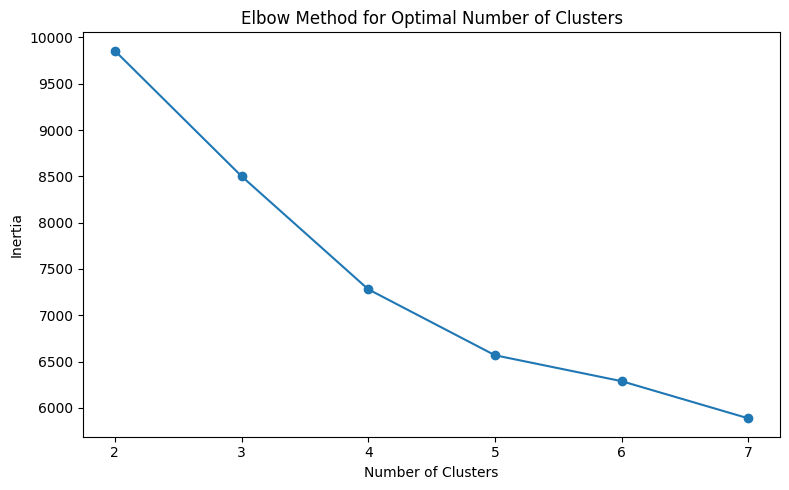

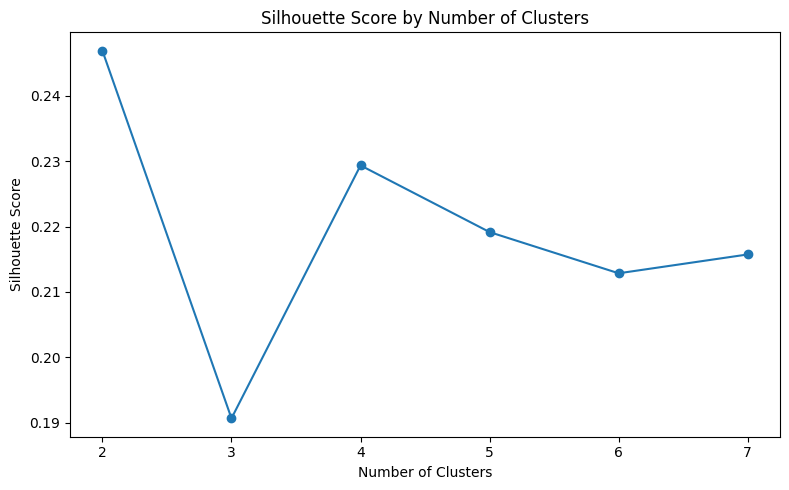


Cluster Summary:
               age        bmi  children       charges
cluster                                              
0        38.673993  33.442418  1.065934   8032.216309
1        39.630847  29.688660  1.098609   8573.029604
2        38.514599  30.708449  1.113139  32050.231832

Risk Distribution:
Medium Risk    791
High Risk      274
Low Risk       273
Name: risk_level, dtype: int64

Sample Output:
   age     sex     bmi  children smoker     region      charges  cluster   risk_level
0   19  female  27.900         0    yes  southwest  16884.92400        2    High Risk
1   18    male  33.770         1     no  southeast   1725.55230        0     Low Risk
2   28    male  33.000         3     no  southeast   4449.46200        0     Low Risk
3   33    male  22.705         0     no  northwest  21984.47061        1  Medium Risk
4   32    male  28.880         0     no  northwest   3866.85520        1  Medium Risk


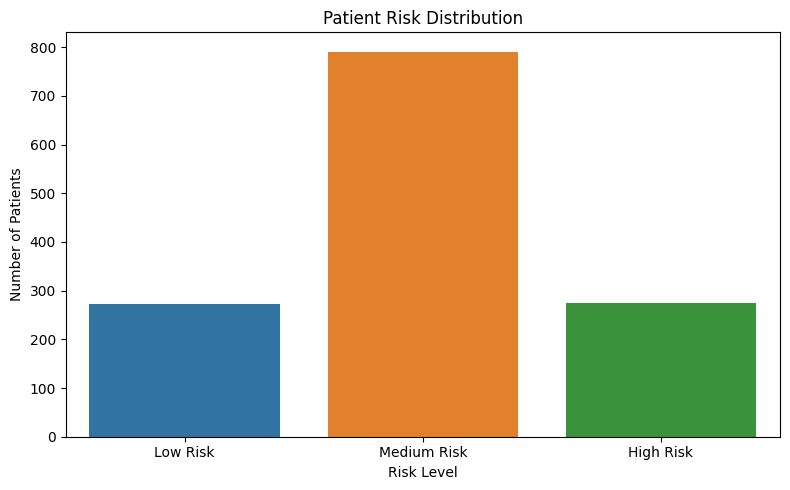

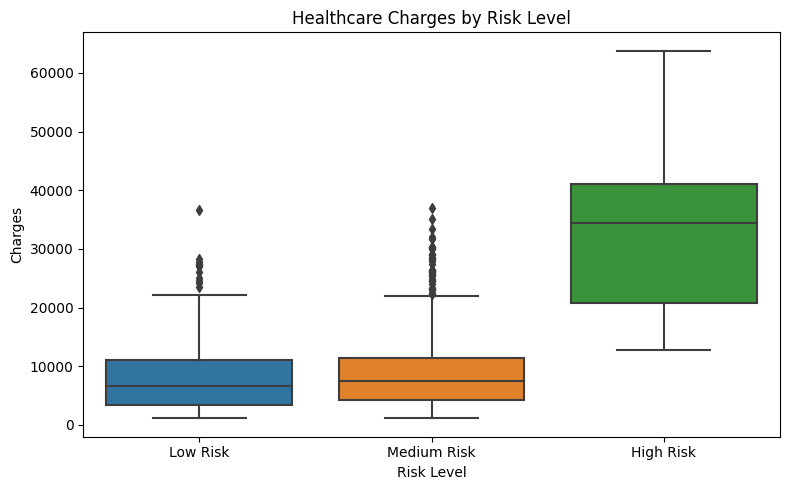

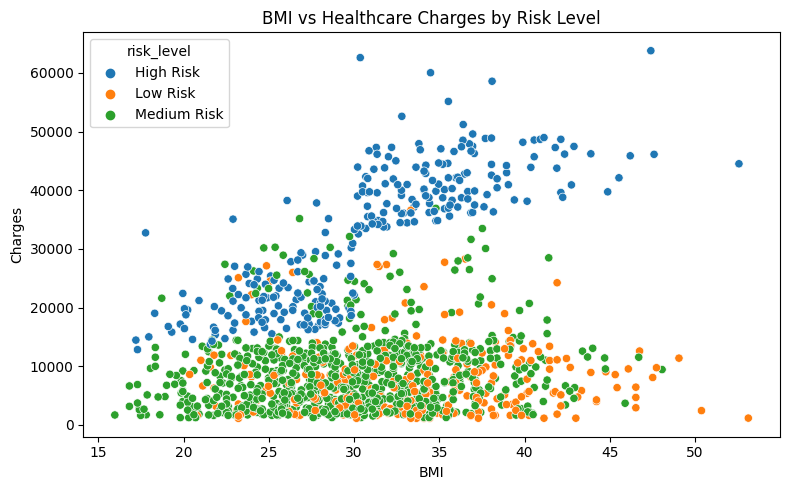

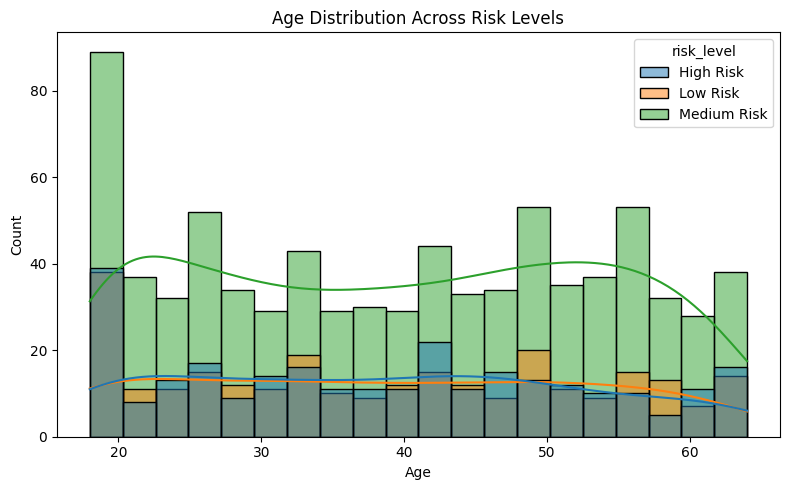

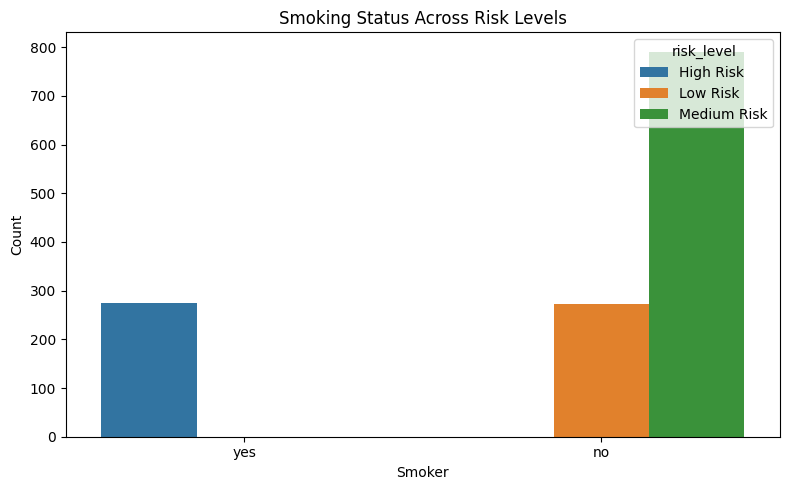

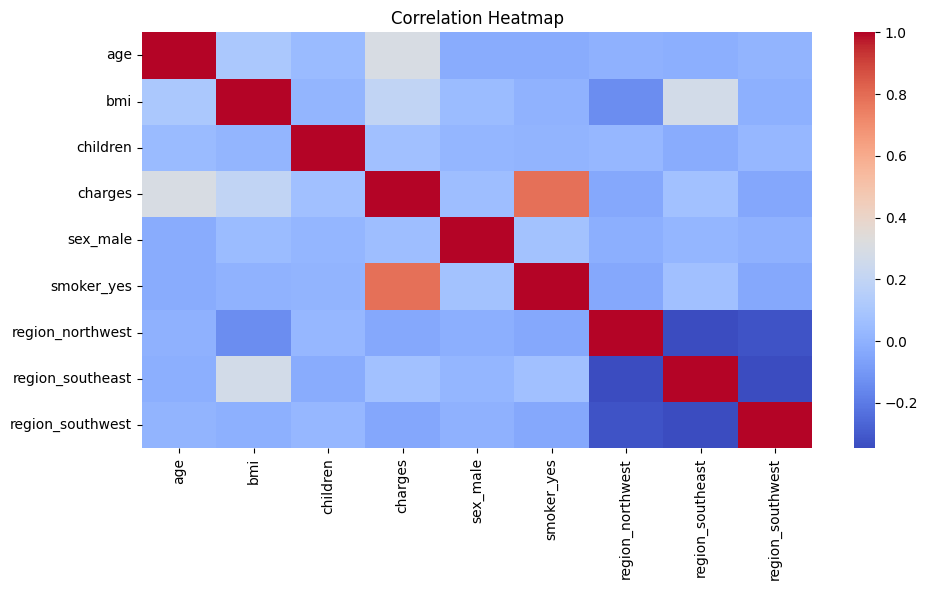

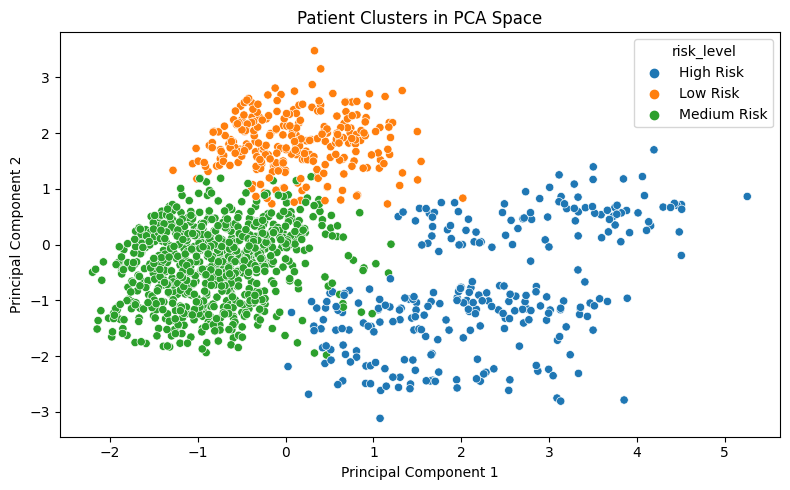


Saved file: patient_risk_output.csv

Project Summary:
This project stratified patients into Low, Medium, and High Risk groups
based on healthcare cost and related demographic/lifestyle factors.
The clustering results can support targeted interventions, resource
allocation, and proactive healthcare management.


In [1]:
# ============================================================
# PATIENT RISK STRATIFICATION BASED ON HEALTHCARE COST
# ============================================================
# Project Goal:
# This project uses unsupervised machine learning to group
# patients into Low, Medium, and High Risk categories based on
# healthcare cost, demographic factors, and lifestyle indicators.
#
# Dataset:
# insurance.csv
#
# Key Features Used:
# - age
# - sex
# - bmi
# - children
# - smoker
# - region
# - charges
#
# Method:
# - Encode categorical variables
# - Scale the data
# - Use KMeans clustering to segment patients
# - Validate the number of clusters using Elbow Method and
#   Silhouette Score
# - Use PCA for 2D visualization
# - Label clusters as Low, Medium, and High Risk based on
#   average healthcare charges
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Improve display format for pandas output
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# 1. LOAD THE DATASET
# ------------------------------------------------------------
# Read the insurance dataset into a pandas DataFrame
df = pd.read_csv("insurance.csv")

# Display the shape and first few records to confirm successful loading
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())

# ------------------------------------------------------------
# 2. ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------
# Machine learning algorithms cannot work directly with text
# columns such as sex, smoker, and region.
# We convert them into numeric format using one-hot encoding.
#
# drop_first=True helps reduce redundancy by dropping one level
# from each categorical variable.
df_encoded = pd.get_dummies(df, drop_first=True)

print("\nEncoded Dataset Shape:", df_encoded.shape)

# ------------------------------------------------------------
# 3. SCALE THE DATA
# ------------------------------------------------------------
# Since clustering is distance-based, all variables need to be
# placed on a comparable scale.
# StandardScaler transforms the data so each feature has:
# - mean = 0
# - standard deviation = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

# ------------------------------------------------------------
# 4. IDENTIFY THE BEST NUMBER OF CLUSTERS
# ------------------------------------------------------------
# We use two methods:
# 1. Elbow Method: checks how inertia changes as clusters increase
# 2. Silhouette Score: measures how well-separated the clusters are
#
# Usually, a good cluster count has:
# - relatively low inertia
# - relatively high silhouette score
inertia = []
sil_scores = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Plot the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. TRAIN THE FINAL CLUSTERING MODEL
# ------------------------------------------------------------
# Based on business interpretation and cluster evaluation,
# we choose 3 clusters:
# - Low Risk
# - Medium Risk
# - High Risk
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# 6. SUMMARISE AND INTERPRET CLUSTERS
# ------------------------------------------------------------
# Group the records by cluster and calculate the average values
# for each cluster. This helps us understand the profile of each
# patient segment.
cluster_summary = df.groupby("cluster").mean(numeric_only=True)

print("\nCluster Summary:")
print(cluster_summary)

# ------------------------------------------------------------
# 7. ASSIGN BUSINESS-FRIENDLY RISK LABELS
# ------------------------------------------------------------
# We interpret the clusters based on average healthcare charges.
# The cluster with the lowest average charge is labeled Low Risk,
# the middle one is labeled Medium Risk,
# and the highest cost cluster is labeled High Risk.
cluster_summary = cluster_summary.sort_values("charges")

risk_map = {
    cluster_summary.index[0]: "Low Risk",
    cluster_summary.index[1]: "Medium Risk",
    cluster_summary.index[2]: "High Risk"
}

df["risk_level"] = df["cluster"].map(risk_map)

# Display how many patients fall into each risk group
print("\nRisk Distribution:")
print(df["risk_level"].value_counts())

# Display a sample of the final dataset
print("\nSample Output:")
print(df.head())

# ------------------------------------------------------------
# 8. DIMENSIONALITY REDUCTION FOR VISUALIZATION
# ------------------------------------------------------------
# Since the dataset contains multiple features, it is difficult
# to visualize clusters directly.
# PCA reduces the dataset to 2 dimensions while preserving as
# much variation as possible, allowing us to plot the clusters.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ------------------------------------------------------------
# 9. VISUALIZATIONS
# ------------------------------------------------------------
# These charts help explain the clusters and support business
# interpretation of the risk groups.

# 9.1 Risk Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="risk_level", order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Patient Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# 9.2 Healthcare Charges by Risk Level
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="risk_level", y="charges", order=["Low Risk", "Medium Risk", "High Risk"])
plt.title("Healthcare Charges by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

# 9.3 BMI vs Charges by Risk Level
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="risk_level")
plt.title("BMI vs Healthcare Charges by Risk Level")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

# 9.4 Age Distribution by Risk Level
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="risk_level", bins=20, kde=True)
plt.title("Age Distribution Across Risk Levels")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 9.5 Smoking Status by Risk Level
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="smoker", hue="risk_level")
plt.title("Smoking Status Across Risk Levels")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 9.6 Correlation Heatmap
# This helps us understand how numerical relationships in the
# encoded dataset may influence clustering structure.
plt.figure(figsize=(10, 6))
corr = df_encoded.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 9.7 PCA Cluster Visualization
# This chart shows the cluster grouping in 2D PCA space.
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["risk_level"])
plt.title("Patient Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. SAVE FINAL OUTPUT
# ------------------------------------------------------------
# Save the final dataset with cluster labels and risk levels
# so it can be used for reporting, dashboards, or further analysis.
df.to_csv("patient_risk_output.csv", index=False)

print("\nSaved file: patient_risk_output.csv")

# ------------------------------------------------------------
# 11. BUSINESS INTERPRETATION
# ------------------------------------------------------------
# Provide a short interpretation of what the model achieved.
print("\nProject Summary:")
print("This project stratified patients into Low, Medium, and High Risk groups")
print("based on healthcare cost and related demographic/lifestyle factors.")
print("The clustering results can support targeted interventions, resource")
print("allocation, and proactive healthcare management.")